<a href="https://colab.research.google.com/github/joaonetto/projetoAplicado-IV/blob/main/notebook/project-ImpossibleTravel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><a href="https://nbviewer.org/github/joaonetto/projetoAplicado-IV/blob/main/notebook/project-ImpossibleTravel.ipynb" target="_parent"><img src="https://img.shields.io/badge/Open%20In%20NBView-blue?logo=javascript"></a>

<img src="https://raw.githubusercontent.com/joaonetto/projetoAplicado-IV/refs/heads/main/Images/Mackenzie.png" width="25%" align="left"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**

---

# **Titulo do Projeto**:

### ***ChronoSec***: Detecção Comportamental e Séries Temporais para Segurança de Login (UEBA) em Eventos Google
---

**Projeto**: *Impossible Travel Detection*

---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'João Silveira Campos Netto, 10441670'  #@param {type:"string"}
Aluno2 = 'Alex Luiz Rabelo, 10442968'  #@param {type:"string"}
Aluno3 = 'Antônio Henrique Caldas Mello, 10433799'  #@param {type:"string"}

## Introdução

Este projeto investiga a detecção de anomalias em processos de autenticação a partir de _logs_ de _login_, com ênfase na identificação de eventos classificados como **Impossible Travel**, isto é, ocorrências em que acessos sucessivos de uma mesma identidade sugerem deslocamentos geográficos incompatíveis com o intervalo de tempo transcorrido entre eles. O principal motivador da proposta reside na necessidade de aprimorar a capacidade de detecção e resposta a possíveis comprometimentos de credenciais, reutilização indevida de sessões e acessos não autorizados em ambientes corporativos distribuídos, especialmente em contextos nos quais usuários, aplicações e serviços operam de forma geograficamente dispersa. Nesse cenário, abordagens baseadas exclusivamente em regras fixas ou limiares rígidos tendem a apresentar limitações relevantes, seja pela elevada sensibilidade a imprecisões de geolocalização, seja pela dificuldade de incorporar variabilidades legítimas de comportamento. Assim, o objetivo geral do projeto consiste em modelar, de forma analítica e adaptativa, a plausibilidade espacial e temporal dos acessos de usuários, produzindo indicadores interpretáveis de risco capazes de subsidiar a priorização de eventos potencialmente críticos.

A proposta adota uma perspectiva de **séries temporais** orientadas a eventos, na qual cada autenticação é compreendida não como uma ocorrência isolada, mas como parte de uma sequência cronológica de acessos associados a uma mesma identidade. Nessa formulação, a ordem dos eventos, o intervalo de tempo entre eles e sua distribuição geográfica tornam-se elementos centrais para a análise. No domínio de segurança, o conceito de **Impossible Travel** emerge justamente da articulação entre essas dimensões, pois um par de _logins_ consecutivos pode ser examinado à luz da distância entre localidades, da duração do deslocamento implícito e da consistência desse movimento com condições minimamente plausíveis do mundo físico. Dessa forma, o projeto busca representar a normalidade de acesso por meio de trajetórias espaço-temporais, permitindo distinguir entre mobilidade legítima, variações esperadas de uso e padrões com maior potencial de indicar anomalia ou abuso de identidade.

Para viabilizar essa modelagem, o núcleo metodológico articula duas camadas complementares de análise. A primeira é determinística e fundamenta-se em cálculo geoespacial, empregando a fórmula de **Haversine** para estimar a distância entre coordenadas geográficas associadas a eventos consecutivos de autenticação. A partir dessa distância e do intervalo temporal entre acessos, calcula-se a velocidade média implícita do deslocamento, incorporando ainda fatores de correção relacionados à incerteza da geolocalização, como o raio de acurácia estimado. Essa etapa tem papel central na formalização da hipótese de **Impossible Travel**, pois traduz registros brutos de autenticação em evidências quantitativas de plausibilidade física. Em termos práticos, o mecanismo transforma pares de eventos em uma métrica objetiva de deslocamento, permitindo avaliar se a sequência observada é compatível com uma movimentação humana plausível ou se revela um padrão cuja velocidade excede limites razoáveis.

A segunda camada metodológica introduz uma dimensão comportamental e preditiva, por meio de redes neurais recorrentes do tipo **Long Short-Term Memory (LSTM)**. Nesse contexto, o modelo é treinado sobre sequências compostas por latitude, longitude e deltas temporais entre eventos, de forma a aprender regularidades associadas às trajetórias observadas no histórico. A importância da **LSTM** decorre de sua capacidade de capturar dependências temporais, preservar contexto sequencial e modelar relações não lineares entre posição geográfica e tempo transcorrido. Mesmo em janelas curtas, o modelo contribui para projetar as observações em um espaço comportamental no qual eventos coerentes com o histórico tendem a ser previstos com maior fidelidade, enquanto eventos atípicos produzem maior erro entre o valor esperado e o efetivamente observado. Nesse sentido, a rede recorrente não substitui a lógica física do **Impossible Travel**, mas a complementa, ao acrescentar uma camada de sensibilidade ao comportamento histórico e à dinâmica individual dos acessos.

A hipótese central do projeto é que eventos compatíveis com trajetórias habituais e fisicamente plausíveis tendem a apresentar, simultaneamente, velocidades coerentes e baixo erro preditivo no modelo sequencial, ao passo que acessos potencialmente anômalos revelam combinações mais discrepantes entre deslocamento geográfico, intervalo temporal e padrão histórico. Dessa forma, a velocidade implícita do deslocamento e o erro de predição comportamental são utilizados como proxies quantitativas de desvio, compondo uma estrutura analítica capaz de apoiar a triagem de eventos em um cenário predominantemente não supervisionado. A partir dessas medidas, o projeto estabelece uma lógica de pontuação contínua para classificar e priorizar ocorrências, permitindo organizar investigações, definir limiares de interesse e agregar evidências por usuário ou por trajetória. Essa estrutura contribui para a sistematização da análise e para a redução do esforço manual, ao transformar registros de autenticação em indicadores comparáveis, interpretáveis e operacionalmente acionáveis no contexto de monitoramento de segurança.

## Referêncial Teórico

A detecção de anomalias em autenticação parte do pressuposto de que eventos de _login_, quando observados em sequência, carregam informação comportamental, espacial e temporal suficiente para distinguir padrões usuais de ocorrências potencialmente maliciosas. Nesse contexto, a solução de **Impossible Travel** insere-se no campo mais amplo de **User and Entity Behavior Analytics (UEBA/UBA)**, abordagem que busca construir perfis de normalidade a partir de evidências operacionais, como horários de acesso, origem geográfica, dispositivos, aplicações e recorrência de uso. Em ambientes de identidade federada e serviços distribuídos, essa lógica tem sido empregada para resumir o comportamento do usuário em “assinaturas” ou _fingerprints_ de sessão, permitindo que desvios sejam tratados como indícios de comprometimento, uso indevido de credenciais ou abuso de acesso. Trabalhos nessa linha mostram que a modelagem do comportamento do usuário é especialmente valiosa quando a segurança não pode depender apenas de regras estáticas, pois a variabilidade legítima entre identidades tende a tornar abordagens rígidas excessivamente sensíveis a falsos positivos.

No problema específico de **Impossible Travel**, o conceito central consiste em verificar se dois eventos consecutivos de autenticação, atribuídos à mesma identidade, implicam um deslocamento geográfico incompatível com o intervalo de tempo transcorrido entre eles. Em termos práticos, compara-se a posição estimada de origem de cada evento, calcula-se a distância entre esses pontos e relaciona-se esse valor ao tempo decorrido, produzindo uma velocidade implícita de deslocamento. Se essa velocidade ultrapassa limites considerados plausíveis, o par de eventos passa a ser tratado como suspeito. Soluções comerciais de identidade e segurança já utilizam essa lógica, mas também reconhecem que o problema real é mais complexo do que uma simples regra geográfica, pois fatores como _VPN_, infraestrutura em nuvem, _NAT_, mobilidade corporativa e imprecisão de geolocalização podem produzir alertas enganosos. Por isso, mecanismos modernos de **Impossible Travel** procuram incorporar contexto adicional e aprendizagem de padrão para reduzir falsos positivos.

Do ponto de vista matemático, a base clássica para esse tipo de solução é o cálculo da distância geográfica entre duas coordenadas de latitude e longitude. Nesse cenário, a fórmula de Haversine é amplamente empregada por estimar a distância de grande círculo entre dois pontos sobre uma esfera a partir de suas coordenadas angulares. Em termos conceituais, ela parte da diferença entre latitudes e longitudes e calcula o menor arco sobre a superfície esférica entre os dois pontos, multiplicando o ângulo central obtido pelo raio médio da Terra. Sua adoção é frequente em aplicações de navegação, localização e segurança porque oferece implementação simples, custo computacional baixo e boa aproximação para muitos cenários práticos. Para um projeto de **Impossible Travel**, isso significa transformar dois **logins** com coordenadas distintas em uma distância objetiva, passível de ser combinada com o intervalo temporal entre acessos para estimar a velocidade média implícita do deslocamento.

Entretanto, embora a fórmula de **Haversine** seja adequada para protótipos e análises operacionais, ela adota uma aproximação esférica da Terra e, por isso, não é a alternativa geodésica mais precisa disponível. Em problemas que exigem maior rigor métrico, sobretudo em longas distâncias ou aplicações cartográficas de alta precisão, são comuns formulações baseadas em modelos elipsoidais, como as fórmulas de **Vincenty**, que tratam a Terra como um elipsoide e oferecem precisão muito superior. A vantagem do **Haversine**, portanto, reside na simplicidade e robustez computacional; sua limitação está no fato de que a distância calculada é aproximada. Já abordagens elipsoidais aumentam a precisão, mas introduzem maior complexidade de implementação. No contexto de autenticação, em que o objetivo não é navegação de precisão centimétrica, mas sim estimativa operacional de plausibilidade, o **Haversine** tende a ser suficiente, especialmente quando combinado com margens de tolerância e metadados de acurácia da geolocalização.

A literatura sobre detecção de anomalias em _logs_ mostra que a simples aplicação de regras fixas raramente esgota o problema. Revisões recentes indicam que os métodos empregados nesse domínio incluem abordagens estatísticas, técnicas de agrupamento, mineração de fluxo de trabalho, análise de frequência temporal e modelos profundos voltados à aprendizagem de padrões normais em sequências de eventos. A principal vantagem das estratégias baseadas em regra é a interpretabilidade imediata: no caso de **Impossible Travel**, o analista consegue explicar de maneira direta que dois _logins_ sucessivos exigiriam uma velocidade incompatível com deslocamento humano plausível. Contudo, a limitação dessas abordagens é sua sensibilidade a exceções de contexto e a dificuldade de generalizar para cenários nos quais o comportamento legítimo é altamente variável. Em contrapartida, técnicas orientadas por dados conseguem capturar regularidades implícitas e adaptar-se melhor ao histórico observado, embora normalmente exijam maior cuidado com treinamento, qualidade dos dados e explicabilidade.

Entre os trabalhos correlacionados mais influentes em modelagem sequencial de _logs_, destaca-se o **DeepLog**, que propõe o uso de redes neurais recorrentes do tipo **LSTM** para modelar _logs_ como sequências e detectar desvios em relação ao comportamento esperado. A contribuição desse trabalho foi demonstrar que eventos de _log_ não precisam ser tratados apenas como ocorrências isoladas; eles podem ser entendidos como estruturas temporais nas quais a ordem importa e a anomalia emerge do afastamento em relação ao padrão normal aprendido. Para problemas de autenticação, essa perspectiva é particularmente relevante, pois acessos sucessivos podem carregar dependências temporais e contextuais que não são capturadas apenas por regras determinísticas. A vantagem da abordagem **LSTM** está em sua capacidade de modelar dependências ao longo do tempo; sua limitação, porém, reside na necessidade de preparação adequada das sequências e na menor transparência interpretativa quando comparada a um critério físico simples, como distância e velocidade.

Em uma direção semelhante, mas com arquitetura distinta, o **LogBERT** transfere para o domínio de _logs_ a lógica de representação contextual dos _Transformers_, utilizando aprendizado autossupervisionado para capturar padrões normais e identificar desvios. Em comparação com arquiteturas recorrentes, modelos baseados em atenção tendem a representar melhor dependências contextuais distribuídas ao longo da sequência, o que pode ser vantajoso em ambientes complexos, com maior variedade de eventos e relações menos locais. Ainda assim, esses modelos costumam demandar mais recursos computacionais, maior volume de dados e _pipeline_ mais sofisticado de treinamento e inferência. Para um projeto como o de **Impossible Travel**, cuja explicabilidade operacional é relevante e cujo objetivo inclui preservar uma forte ligação entre indício analítico e plausibilidade física, a adoção de um modelo sequencial mais simples, como **LSTM**, pode representar um compromisso metodológico adequado entre capacidade de aprendizado e viabilidade de implementação.

Outra família de soluções correlatas é a dos _autoencoders_, amplamente utilizada em detecção não supervisionada de anomalias. Nessa estratégia, o modelo é treinado para reconstruir padrões normais; quando recebe um evento ou sequência fora da distribuição esperada, tende a produzir maior erro de reconstrução, que passa a funcionar como _proxy_ de desvio. Trabalhos aplicados a comportamento interno, autenticação e _logs_ de identidade mostram que _autoencoders_, inclusive com **LSTM**, são úteis quando há escassez de rótulos confiáveis de ataque e quando se deseja modelar a normalidade sem enumerar previamente todos os cenários anômalos possíveis. Em _logs_ de autenticação, essa abordagem é atraente porque credenciais comprometidas e acessos indevidos nem sempre produzem assinaturas rígidas e repetitivas; muitas vezes, o evento suspeito é justamente aquele que parece “estatisticamente estranho” em relação ao histórico do usuário. A vantagem dessa linha está em sua adequação a cenários não supervisionados; a limitação está no fato de que o erro do modelo nem sempre é imediatamente interpretável do ponto de vista operacional sem uma camada adicional de contexto.

À luz desses trabalhos, a alternativa adotada neste projeto, combinar cálculo geoespacial com modelagem sequencial comportamental, pode ser entendida como uma solução híbrida. A parte geográfica, baseada em **Haversine**, responde à pergunta física elementar: **“o deslocamento implícito entre dois logins é plausível?”**. A parte sequencial, implementada com **LSTM**, responde a uma pergunta complementar: **“mesmo que a regra geográfica sinalize risco, esse evento também se afasta do padrão histórico aprendido para a identidade ou para a trajetória observada?”**. Essa composição apresenta uma vantagem importante em relação a soluções puramente determinísticas, porque reduz a dependência de um único critério; e também apresenta uma vantagem em relação a soluções puramente comportamentais, porque preserva um eixo de interpretabilidade forte, ancorado em espaço, tempo e velocidade. Sua principal limitação continua sendo a qualidade da geolocalização por _IP_ e a necessidade de tratar contextos benignos que podem imitar **Impossible Travel**, como _VPNs_, _proxies_ corporativos e infraestruturas distribuídas, razão pela qual sistemas maduros do mercado também recorrem a filtragem contextual e aprendizado de padrão.

Em síntese, o referencial teórico do problema mostra que **Impossible Travel** não deve ser visto apenas como uma regra de distância dividida pelo tempo, mas como um caso particular de detecção de anomalias em identidade digital, situado na interseção entre **UEBA**, análise de _logs_, modelagem espaço-temporal e aprendizado de máquina. A literatura correlata sustenta que métodos baseados exclusivamente em regras oferecem clareza e rastreabilidade, mas tendem a sofrer com rigidez e falso positivo; por outro lado, métodos baseados em modelagem sequencial, _autoencoders_ e arquiteturas profundas ampliam a sensibilidade a padrões complexos, embora tragam desafios de explicabilidade e custo analítico. Nesse equilíbrio, a solução híbrida proposta mostra aderência tanto ao fundamento físico do deslocamento geográfico quanto à necessidade contemporânea de interpretar autenticações como trajetórias comportamentais, e não apenas como eventos isolados.

## Referências

MARTÍN, Alejandro G.; BELTRÁN, Marta; FERNÁNDEZ-ISABEL, Alberto; MARTÍN DE DIEGO, Isaac. An approach to detect user behaviour anomalies within identity federations. Computers & Security, v. 108, 102356, set. 2021. Disponível em: https://www.sciencedirect.com/science/article/pii/S0167404821001802. Acesso em: 1 mar. 2026.

KIM, Seo-Yi; LEE, Il-Gu. LSTM autoencoder-based insider abnormal behavior detection using de-identified data. In: INTERNATIONAL CONFERENCE ON INFORMATION SYSTEMS SECURITY AND PRIVACY, 10., 2024. Proceedings […] [S. l.]: SCITEPRESS, 2024. p. 609-620. Disponível em: https://www.scitepress.org/Papers/2024/124580/124580.pdf. Acesso em: 2 mar. 2026.

MICROSOFT. Create Defender for Cloud Apps anomaly detection policies. Microsoft Learn, [s. l.], 2025. Disponível em: https://learn.microsoft.com/en-us/defender-cloud-apps/anomaly-detection-policy. Acesso em: 27 fev. 2026.

GUO, Haixuan; YUAN, Shuhan; WU, Xintao. LogBERT: log anomaly detection via BERT. arXiv, 2021. Disponível em: https://arxiv.org/pdf/2103.04475. Acesso em: 27 fev. 2026.

DU, Min; LI, Feifei; ZHENG, Guineng; SRIKUMAR, Vivek. DeepLog: anomaly detection and diagnosis from system logs through deep learning. In: ACM SIGSAC CONFERENCE ON COMPUTER AND COMMUNICATIONS SECURITY, 24., 2017, Dallas, TX, USA. Proceedings […] New York, NY: ACM, 2017. Disponível em: https://users.cs.utah.edu/~lifeifei/papers/deeplog.pdf. Acesso em: 25 fev. 2026.

LANDAUER, Max; ONDER, Sebastian; SKOPIK, Florian; WURZENBERGER, Markus. Deep learning for anomaly detection in log data: a survey. arXiv, 2022. Disponível em: https://arxiv.org/pdf/2207.03820. Acesso em: 25 fev. 2026.

## Diagrama da Solução

<img src="https://github.com/joaonetto/projetoAplicado-IV/blob/main/Images/ImpossibleTravel.jpg?raw=true" width="100%"/>

O diagrama apresentado representa uma arquitetura em nuvem para detecção de anomalias de autenticação com foco em **Impossible Travel**, estruturada como um pipeline contínuo de ingestão, enriquecimento, modelagem comportamental e priorização investigativa. Em termos conceituais, a figura organiza o problema como um fluxo analítico orientado a eventos, no qual registros de autenticação e dados de localização são capturados, transformados em atributos espaço-temporais, submetidos a mecanismos de detecção determinística e comportamental, e finalmente convertidos em alertas operacionais para um centro de operações de segurança.

Na porção esquerda do diagrama, observa-se a camada de origem de dados, composta por múltiplas fontes de autenticação, representadas por dispositivos, servidores e registros de _auth logs_. Essa representação sugere um ambiente distribuído, no qual os eventos são gerados por diferentes ativos e aplicações, refletindo uma realidade comum em ecossistemas corporativos híbridos e em nuvem. Associados a esses eventos aparecem dados de localização, indicando que cada autenticação não é tratada apenas como um registro lógico de acesso, mas como uma observação enriquecida com contexto geográfico. Essa decisão arquitetural é central para o problema de **Impossible Travel**, pois a inferência de plausibilidade depende precisamente da combinação entre identidade, tempo e posição geográfica estimada.

Em seguida, o diagrama apresenta uma etapa de **Streaming Event Ingestion**, explicitamente associada a tecnologias de _streaming_, o que caracteriza a proposta como aderente a uma arquitetura de processamento de eventos em fluxo contínuo. Sob uma perspectiva técnica, essa camada desempenha o papel de desacoplamento entre a geração e o processamento dos dados, permitindo escalabilidade, tolerância a picos de volume e tratamento quase em tempo real. Em projetos de segurança, essa característica é particularmente relevante, pois reduz a latência entre a ocorrência do evento e sua avaliação analítica, ampliando a capacidade de resposta do **SOC**. Além disso, a presença de uma esteira de ingestão indica uma operação contínua, e não apenas em modo **batch**, o que é compatível com cenários em que autenticações precisam ser avaliadas à medida que ocorrem.

No interior da nuvem, a primeira grande etapa analítica é identificada como **Geotemporal Feature Correlation Engine**. Essa camada tem função de engenharia de atributos, correlacionando os eventos brutos com variáveis temporais e geográficas. O diagrama explicita elementos como hora do dia e dia da semana, sinalizando que o projeto não se limita ao cálculo de deslocamento físico entre localidades, mas incorpora também dimensões cíclicas do comportamento do usuário. Em termos acadêmicos, essa etapa corresponde à construção de uma representação espaço-temporal dos acessos, na qual cada autenticação passa a ser entendida como uma observação inserida em uma trajetória. A inclusão dessas variáveis reforça a proximidade do projeto com abordagens de **User Behaviour Analysis (UBA)**, pois permite distinguir não apenas “de onde” e “quando” o acesso ocorreu, mas também se esse evento se alinha ao padrão recorrente da identidade observada.

A camada seguinte, representada como **LSTM Autoencoder** (**Geo-Behavioral UBA Profiling**), constitui o núcleo de modelagem comportamental da arquitetura. O diagrama sugere que o evento de entrada é processado por uma rede neural recorrente do tipo **LSTM**, cuja função é aprender um _baseline_ geocomportamental do usuário e reconstruir o padrão esperado. Do ponto de vista metodológico, trata-se de uma formulação típica de detecção de anomalias não supervisionada, em que o modelo aprende regularidades históricas e produz erro maior quando confrontado com observações discrepantes. A presença do _autoencoder_ indica que a arquitetura busca representar o comportamento normal em um espaço latente, comprimindo dependências implícitas entre localização, tempo e sequência de acessos. Assim, a contribuição dessa camada é complementar ao mecanismo determinístico de **Impossible Travel**: enquanto a regra física verifica a plausibilidade do deslocamento, o modelo recorrente avalia se a trajetória observada é coerente com o histórico aprendido.

Paralelamente, o diagrama destaca um **Impossible Travel Calculation Engine**, evidenciando que a arquitetura mantém uma camada analítica explicitamente dedicada ao cálculo da inviabilidade de deslocamento. A ilustração sugere a comparação entre duas localizações associadas a tempos distintos, seguida por uma operação matemática que resulta em um indicador de viabilidade. Em termos técnicos, essa camada pode ser interpretada como a implementação do cálculo de distância geográfica, tipicamente via fórmula de Haversine — combinado com o intervalo temporal entre eventos para estimar a velocidade implícita de deslocamento. A principal relevância dessa etapa reside na sua elevada interpretabilidade: ela traduz eventos de autenticação em uma métrica física objetiva, permitindo justificar o alerta com base em distância, tempo transcorrido e velocidade estimada. Em ambientes operacionais, essa explicabilidade é essencial para a triagem, pois oferece ao analista uma evidência concreta e facilmente comunicável.

Na continuidade do fluxo, o diagrama apresenta um **Anomaly Scoring Engine**, que consolida os resultados das camadas anteriores em uma métrica unificada de risco. Essa etapa é particularmente importante em arquiteturas híbridas, pois permite combinar sinais heterogêneos, por exemplo, velocidade implícita do deslocamento, erro de reconstrução do _autoencoder_, frequência histórica de eventos semelhantes e eventual contexto adicional, em um único _score_ analítico. A figura destaca o resultado **“Travel Unfeasible”**, acompanhado por um medidor em zona crítica, sugerindo que o sistema transforma variáveis contínuas em um julgamento operacional priorizável. Em termos acadêmicos, isso corresponde à etapa de fusão de evidências, na qual sinais distintos são integrados para apoiar decisão, reduzindo dependência de critérios isolados e favorecendo uma classificação mais robusta dos eventos suspeitos.

Outro componente relevante do diagrama é o **User Profile Store & Historical DB**, que funciona como repositório persistente de perfis e histórico. Essa camada é fundamental para a sustentação do modelo de **UBA**, pois o aprendizado comportamental depende da manutenção de memória histórica sobre cada identidade ou entidade monitorada. Sob a ótica arquitetural, esse repositório cumpre ao menos três funções: armazenar eventos passados para treinamento e reprocessamento, preservar perfis derivados das rotinas observadas e fornecer contexto histórico para inferência em tempo real. Sem essa camada, a análise se limitaria ao evento isolado; com ela, o sistema passa a operar orientado por trajetória, continuidade e contexto acumulado. Trata-se, portanto, de um elemento indispensável para que a arquitetura transcenda a simples detecção reativa e avance em direção a uma análise comportamental persistente.

Na extremidade direita, o diagrama mostra a integração com uma **Security Operations Center (SOC)**, na qual o resultado final do _pipeline_ é apresentado como alerta crítico de **Impossible Travel** para priorização de investigação. Esse componente traduz a arquitetura analítica em capacidade operacional, conectando o mecanismo de detecção à atividade humana de triagem, validação e resposta. O painel visualiza um mapa, uma linha temporal e um gráfico de score, sugerindo que o sistema não apenas alerta, mas também oferece elementos de contextualização para apoiar a decisão do analista. Em termos de desenho de solução, isso evidencia uma preocupação com a operacionalização do modelo, isto é, com a transformação do resultado analítico em informação acionável no contexto do **SOC**.

De forma mais ampla, o diagrama expressa uma arquitetura híbrida, escalável e explicável. Híbrida porque combina uma lógica física e determinística de deslocamento com uma lógica comportamental e probabilística baseada em aprendizado de máquina. Escalável porque utiliza ingestão em _streaming_ e componentes desacoplados, adequados a ambientes de nuvem e alta volumetria. Explicável porque preserva um eixo de interpretação fundamentado em distância, tempo e inviabilidade de deslocamento, evitando que toda a decisão dependa exclusivamente de um modelo opaco. Essa combinação é particularmente adequada ao problema de **Impossible Travel**, pois responde tanto à necessidade de rigor técnico quanto à necessidade de aplicabilidade operacional.

# Detecção de Impossible Travel em Logs de Acesso

Este notebook identifica acessos suspeitos baseados na lógica de **viagem impossível** e utiliza **Redes Neurais Recorrentes (LSTM)** para modelar comportamentos de geolocalização, aproveitando a aceleração de hardware **Apple Silicon (M2)**.

### Estrutura do Projeto:
1. **Configuração de Ambiente**: Verificação de suporte a GPU (Metal).
2. **Detecção Determinística**: Baseada em velocidade física (Haversine).
3. **Modelagem Comportamental Global (LSTM)**: Treinamento com contexto de geolocalização e tempo.
4. **Visualização de Performance**: Gráfico de Perda (Loss) vs Validação.
5. **Apresentação de Casos**: Cruzamento de dados físicos e comportamentais.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
from datetime import datetime, timedelta
from IPython.display import display, HTML
import folium
from sklearn.preprocessing import MinMaxScaler

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    print("Versão do TensorFlow:", tf.__version__)
    dispositivos_gpu = tf.config.list_physical_devices('GPU')

    if dispositivos_gpu:
        print("\n✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.")
    else:
        print("\n⚠️ Nenhuma GPU detectada. O treinamento ocorrerá na CPU.")
except ImportError:
    print("TensorFlow não encontrado.")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

Versão do TensorFlow: 2.19.0

⚠️ Nenhuma GPU detectada. O treinamento ocorrerá na CPU.


In [3]:
#
# Variáveis
#

# Entrada de Dados
PATH = [
    "content",
    "drive",
    "MyDrive",
    "Mackenzie",
    "5o Semestre",
    "PA4 - Projeto Aplicado - IV",
    "Code",
    "projetoAplicado-IV",
    "Data"
]
FILENAME = "saida_enriquecida.csv"
SEP = ","
INPUT_CSV = "/"
SEQ_LENGTH = 1

for p in PATH:
    INPUT_CSV += p + "/"

INPUT_CSV += FILENAME

## 1. Carregamento e Preparação de Dados

In [4]:
df = pd.read_csv(INPUT_CSV, sep=SEP)
cols_essenciais = ['Data', 'Usuário', 'Evento', 'latitude', 'longitude', 'accuracy_radius_km', 'cidade', 'Descrição']
df = df[cols_essenciais]

df['full_log'] = df.apply(lambda x: ';'.join(map(str, x)), axis=1)
df['Data'] = pd.to_datetime(df['Data'])

df_success = df[df['Evento'] == 'login_success'].copy()
df_success = df_success.sort_values(by=['Usuário', 'Data'])

print(f"Base preparada com {len(df_success)} registros de login.")

Base preparada com 388667 registros de login.


## 2. Processamento de Velocidade Física (Haversine)

Cálculo da velocidade entre acessos consecutivos para classificação de prioridade determinística.

In [5]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371

df_success['prev_data'] = df_success.groupby('Usuário')['Data'].shift(1)
df_success['prev_lat'] = df_success.groupby('Usuário')['latitude'].shift(1)
df_success['prev_lon'] = df_success.groupby('Usuário')['longitude'].shift(1)
df_success['prev_cidade'] = df_success.groupby('Usuário')['cidade'].shift(1)
df_success['prev_full_log'] = df_success.groupby('Usuário')['full_log'].shift(1)
df_success['prev_accuracy'] = df_success.groupby('Usuário')['accuracy_radius_km'].shift(1)

df_analysis = df_success.dropna(subset=['prev_data']).copy()

def calculate_travel(row):
    dist = haversine(row['longitude'], row['latitude'], row['prev_lon'], row['prev_lat'])
    min_dist = max(0, dist - (row['accuracy_radius_km'] + row['prev_accuracy']))
    diff_seconds = (row['Data'] - row['prev_data']).total_seconds()
    hours = diff_seconds / 3600
    speed = min_dist / hours if hours > 0 else 0
    return pd.Series([dist, min_dist, hours, speed, diff_seconds])

df_analysis[['dist_km', 'min_dist_km', 'time_diff_hours', 'speed_kmh', 'time_delta_sec']] = df_analysis.apply(calculate_travel, axis=1)

## 3. Preparação para Treinamento LSTM (Feature Temporal)

Adicionamos o `time_delta_sec` para que o modelo entenda a relação tempo-espaço.

In [6]:
def build_global_sequences(df, n_steps=3):
    X_global, y_global, indices = [], [], []
    scaler = MinMaxScaler()

    df['time_delta_sec'] = df.groupby('Usuário')['Data'].diff().dt.total_seconds().fillna(0)

    features_to_scale = ['latitude', 'longitude', 'time_delta_sec']
    df.loc[:, ['lat_s', 'lon_s', 'time_s']] = scaler.fit_transform(df[features_to_scale])

    for user, group in df.groupby('Usuário'):
        if len(group) > n_steps:
            user_data = group[['lat_s', 'lon_s', 'time_s']].values
            idx_list = group.index.tolist()
            for i in range(len(user_data) - n_steps):
                X_global.append(user_data[i : i + n_steps])
                y_global.append(user_data[i + n_steps, :2])
                indices.append(idx_list[i + n_steps])

    return np.array(X_global), np.array(y_global), scaler, indices

N_STEPS = 3
X_train, y_train, master_scaler, target_indices = build_global_sequences(df_success, n_steps=N_STEPS)
print(f"Dataset pronto para GPU: {X_train.shape}")

Dataset pronto para GPU: (374017, 3, 3)


## 4. Treinamento e Performance do Modelo

Treinamos o modelo e plotamos a evolução do erro médio quadrático.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Iniciando Treinamento Global Acelerado ---

Epoch 1/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 68s 14ms/step - loss: 0.0012 - val_loss: 4.2262e-04
Epoch 2/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 66s 14ms/step - loss: 2.7024e-04 - val_loss: 2.7581e-04
Epoch 3/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 65s 14ms/step - loss: 2.4332e-04 - val_loss: 2.8298e-04
Epoch 4/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 2.5031e-04 - val_loss: 2.7005e-04
Epoch 5/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 65s 14ms/step - loss: 2.4391e-04 - val_loss: 2.6012e-04
Epoch 6/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 66s 14ms/step - loss: 2.5363e-04 - val_loss: 2.7717e-04
Epoch 7/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 65s 14ms/step - loss: 2.6079e-04 - val_loss: 2.6005e-04
Epoch 8/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 66s 14ms/step - loss: 2.4878e-04 - val_loss: 2.7055e-04
Epoch 9/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 63s 14ms/step - loss: 2.5224e-04 - val_loss: 2.5827e-04
Epoch 10/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 70s 15ms/step - loss: 2.5717e-

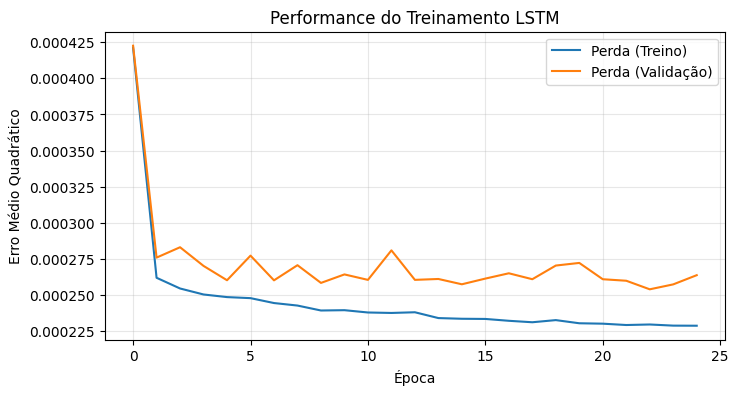

11689/11689 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step


In [7]:
if X_train.shape[0] > 0:
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(N_STEPS, 3), return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh'),
        Dense(2)
    ])

    model.compile(optimizer='adam', loss='mse')

    print("\n--- Iniciando Treinamento Global Acelerado ---\n")
    # Armazenamos o histórico de treinamento
    history = model.fit(X_train, y_train, epochs=25, batch_size=64, verbose=1, validation_split=0.2)

    # --- GRÁFICO DE PERFORMANCE DE TREINAMENTO ---
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Perda (Treino)')
    plt.plot(history.history['val_loss'], label='Perda (Validação)')
    plt.title('Performance do Treinamento LSTM')
    plt.xlabel('Época')
    plt.ylabel('Erro Médio Quadrático')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Cálculo do Erro Comportamental
    y_pred = model.predict(X_train)
    errors = np.linalg.norm(y_train - y_pred, axis=1)

    df_analysis['score_comportamental'] = 0.0
    for i, idx in enumerate(target_indices):
        if idx in df_analysis.index:
            df_analysis.at[idx, 'score_comportamental'] = float(errors[i])

## 5. Investigação de Estudos de Caso (Análise Forense)

In [8]:
def format_timedelta(hours_decimal):
    td = timedelta(hours=hours_decimal)
    total_seconds = int(td.total_seconds())
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

def apresentar_estudo_caso(df_subset, titulo, cor_mapa):
    display(HTML(f"<h2 style='color:{cor_mapa}; border-bottom: 2px solid {cor_mapa};'>{titulo}</h2>"))
    if df_subset.empty: return

    top_casos = df_subset.sort_values(by=['speed_kmh', 'score_comportamental'], ascending=False).head(4)
    threshold = df_analysis['score_comportamental'].mean() + (2 * df_analysis['score_comportamental'].std())

    for i, (idx, row) in enumerate(top_casos.iterrows()):
        print(f"CASO #{i+1}")
        print(f"Usuário: {row['Usuário']}")
        print(f"Origem:\n    - Horário: {row['prev_data']}\n    - Cidade: {row['prev_cidade']}\n    - Log: {row['prev_full_log']}")
        print(f"Destino:\n    - Horário: {row['Data']}\n    - Cidade: {row['cidade']}\n    - Log: {row['full_log']}")
        print(f"Velocidade Calculada: {row['speed_kmh']:.2f} km/h")
        print(f"Diferença Temporal: {format_timedelta(row['time_diff_hours'])} (HH:MM:SS)")
        print(f"Distância: {row['min_dist_km']:.2f} km")

        is_anomalous = row['score_comportamental'] > threshold
        print(f"Score Comportamental (LSTM): {row['score_comportamental']:.6f} ({'ANÔMALO' if is_anomalous else 'ESPERADO'})")

        m = folium.Map(location=[(row['prev_lat']+row['latitude'])/2, (row['prev_lon']+row['longitude'])/2], zoom_start=2)
        folium.Marker([row['prev_lat'], row['prev_lon']], icon=folium.Icon(color='blue')).add_to(m)
        folium.Marker([row['latitude'], row['longitude']], icon=folium.Icon(color='red')).add_to(m)
        folium.PolyLine([[row['prev_lat'], row['prev_lon']], [row['latitude'], row['longitude']]], color=cor_mapa, weight=3).add_to(m)
        display(m)

        # Adição da Ação Adicional: Link externo para o Google Maps
        gmaps_link = f"https://www.google.com/maps/dir/{row['prev_lat']},{row['prev_lon']}/{row['latitude']},{row['longitude']}/"
        display(HTML(f'<b>Ação Adicional:</b> <a href="{gmaps_link}" target="_blank">Ver detalhes no Google Maps Externo</a>'))

        print("-" * 80)

alta = df_analysis[df_analysis['speed_kmh'] > 1000]
apresentar_estudo_caso(alta, "Alta Prioridade (Detecção Crítica)", "#d9534f")

CASO #1
Usuário: USR502440@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-01-07 12:08:03-03:00
    - Cidade: Woldingham
    - Log: 2025-01-07T12:08:03-0300;USR502440@acme-d67a0e6c.org.br;login_success;51.28348;-0.0352;10.0;Woldingham;USR502440@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-01-07 12:08:10-03:00
    - Cidade: São Paulo
    - Log: 2025-01-07T12:08:10-0300;USR502440@acme-d67a0e6c.org.br;login_success;-23.6293;-46.6351;20.0;São Paulo;USR502440@acme-d67a0e6c.org.br logged in
Velocidade Calculada: 4865676.71 km/h
Diferença Temporal: 00:00:07 (HH:MM:SS)
Distância: 9461.04 km
Score Comportamental (LSTM): 0.000000 (ESPERADO)


--------------------------------------------------------------------------------
CASO #2
Usuário: USR448151@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-04-28 12:54:38-03:00
    - Cidade: São Paulo
    - Log: 2025-04-28T12:54:38-0300;USR448151@acme-d67a0e6c.org.br;login_success;-23.5475;-46.6361;5.0;São Paulo;USR448151@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-04-28 12:54:39-03:00
    - Cidade: Ituiutaba
    - Log: 2025-04-28T12:54:39-0300;USR448151@acme-d67a0e6c.org.br;login_success;-19.0137;-49.5496;5.0;Ituiutaba;USR448151@acme-d67a0e6c.org.br logged in
Velocidade Calculada: 2079165.54 km/h
Diferença Temporal: 00:00:01 (HH:MM:SS)
Distância: 577.55 km
Score Comportamental (LSTM): 0.045257 (ANÔMALO)


--------------------------------------------------------------------------------
CASO #3
Usuário: USR459166@acme-043bf1cc.org.br
Origem:
    - Horário: 2025-05-09 09:49:02-03:00
    - Cidade: Naaldwijk
    - Log: 2025-05-09T09:49:02-0300;USR459166@acme-043bf1cc.org.br;login_success;51.9968;4.2057;20.0;Naaldwijk;USR459166@acme-043bf1cc.org.br logged in
Destino:
    - Horário: 2025-05-09 09:49:19-03:00
    - Cidade: São Paulo
    - Log: 2025-05-09T09:49:19-0300;USR459166@acme-043bf1cc.org.br;login_success;-23.6293;-46.6351;10.0;São Paulo;USR459166@acme-043bf1cc.org.br logged in
Velocidade Calculada: 2058409.95 km/h
Diferença Temporal: 00:00:17 (HH:MM:SS)
Distância: 9720.27 km
Score Comportamental (LSTM): 0.537736 (ANÔMALO)


--------------------------------------------------------------------------------
CASO #4
Usuário: USR975404@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-01-26 20:35:47-03:00
    - Cidade: Amsterdam
    - Log: 2025-01-26T20:35:47-0300;USR975404@acme-4cdbb9e8.org.br;login_success;52.13263;5.29127;50.0;Amsterdam;USR975404@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-01-26 20:36:09-03:00
    - Cidade: São Paulo
    - Log: 2025-01-26T20:36:09-0300;USR975404@acme-4cdbb9e8.org.br;login_success;-23.5475;-46.6361;5.0;São Paulo;USR975404@acme-4cdbb9e8.org.br logged in
Velocidade Calculada: 1595626.26 km/h
Diferença Temporal: 00:00:22 (HH:MM:SS)
Distância: 9751.05 km
Score Comportamental (LSTM): 0.286485 (ANÔMALO)


--------------------------------------------------------------------------------


## 6. Conclusão e Exportação

In [ ]:
alta.to_csv('alertas_prioridade_alta.csv', index=False, sep=';')
print("Análise finalizada com diagnóstico de performance de treino.")

Análise finalizada com diagnóstico de performance de treino.
